[[0, 0, 0], [0.75, 1.8, 2.3333333333333335], [0.8833333333333333, 1.0333333333333332, 1.4833333333333334], [0.8625, 1.15, 1.6944444444444446], [0.8861111111111112, 1.116111111111111, 1.6625000000000003], [0.8865972222222223, 1.1130555555555555, 1.6659259259259258], [0.8882175925925926, 1.112175925925926, 1.6667824074074076], [0.8886516203703704, 1.1113564814814814, 1.6665354938271604], [0.8887947530864198, 1.1112322530864198, 1.6666639660493827], [0.8888579282407407, 1.1111493055555557, 1.6666576646090536], [0.8888770897633744, 1.111125295781893, 1.6666642554012345], [0.8888847399048354, 1.1111163130144033, 1.666665871484911], [0.8888873896176269, 1.1111129297410838, 1.6666663156935873], [0.8888883464881259, 1.1111117810142317, 1.6666665602137634], [0.8888886947998829, 1.1111113493619968, 1.666666624165881], [0.888888818700971, 1.1111111972468706, 1.6666666519460402], [0.8888888636747925, 1.1111111421304034, 1.6666666613507195], [0.888888879805079, 1.111111122259939, 1.6666666647316013

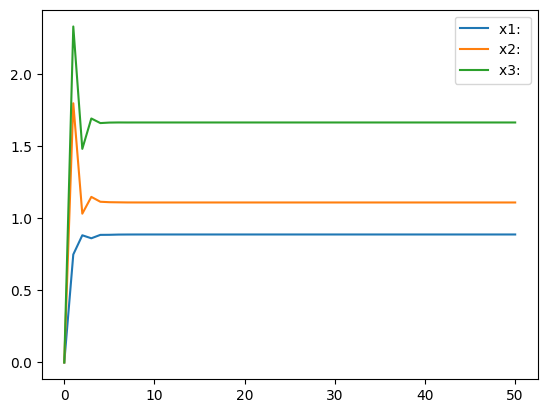

0.8888888888888888 1.1111111111111112 1.6666666666666667


In [8]:
# Matrix Manupilation
import numpy as np
import matplotlib.pyplot as plt

def input_matrix(m, n):
    A = []
    for i in range(m):
        ac = []
        for j in range(n):
            aij = float(input(f"Give A({i,j}): "))
            ac.append(aij)

        A.append(ac)
    return A

def jacobian_matrix_eq(A, X, B):
    X_new = []
    for i in range(n):
        temp_x = B[i]
        # if i > 0:
        #     for j in range(0, i):
        #         temp_x -= A[i, j] * X[j]
        # if i < n-1:
        for j in range(0, n):
            if j != i:
                temp_x -= A[i, j] * X[j]

        temp_x /= A[i, i]
        X_new.append(float(temp_x))

    return X_new

n = 3

# A = np.random.randint(-10, 10, size = (n, n))
X = np.zeros([n])
# B = np.random.randint(-10, 10, size = (n))

A = np.array([[4, 1, -1], [2, 5, 1], [1, 1, 3]])

B = [3, 9, 7]

n_max = 50

X_arr = [[0, 0, 0]]
for _ in range(n_max):
    Xn = jacobian_matrix_eq(A, X_arr[-1], B)
    X_arr.append(Xn)

print(X_arr)

x1, x2, x3, x4 = [], [], [], []

for x0 in X_arr:
    x1.append(x0[0])
    x2.append(x0[1])
    x3.append(x0[2])


t = range(len(X_arr))

plt.plot(t, x1, label = "x1: ")
plt.plot(t, x2, label = "x2: ")
plt.plot(t, x3, label = "x3: ")
plt.legend()
plt.show()
print(x1[-1], x2[-1], x3[-1])

In [4]:
# Gaussian Elimination Method
import numpy as np

def gaussian_elimination(A, B):
    n = len(B)
    A = A.copy()
    B = B.copy()
    
    # Forward elimination
    for i in range(n):
        # Partial pivoting
        max_row = i
        for k in range(i+1, n):
            if abs(A[k][i]) > abs(A[max_row][i]):
                max_row = k
        
        # Swap rows properly
        temp_row = A[i].copy()
        A[i] = A[max_row]
        A[max_row] = temp_row
        
        temp_b = B[i]
        B[i] = B[max_row]
        B[max_row] = temp_b
        
        # Eliminate below
        for k in range(i+1, n):
            factor = A[k][i] / A[i][i]
            for j in range(i, n):
                A[k][j] = A[k][j] - factor * A[i][j]
            B[k] = B[k] - factor * B[i]
    
    # Back substitution
    X = [0.0] * n
    
    for i in range(n-1, -1, -1):
        temp_sum = B[i]
        for j in range(i+1, n):
            temp_sum = temp_sum - A[i][j] * X[j]
        X[i] = float(temp_sum / A[i][i])
    
    return X

n = 3

A = np.array([[4, 1, -1],
              [2, 5, 1],
              [1, 1, 3]],
              dtype=float)

B = np.array([3,
              9,
              7],
             dtype=float)

X = gaussian_elimination(A, B)

# print(X)
print("\n",X[0],
      "\n",X[1],
      "\n",X[2])



 0.8888888888888888 
 1.1111111111111112 
 1.6666666666666667
